# PRG Toolbox Tutorial: fMRI Data Binarization

This notebook provides a practical demonstration of how to use the Phenomenological Renormalization Group (PRG) toolbox to analyze continuous, high-dimensional datasets.

To illustrate the PRG pipeline for continuous signals, we will analyze functional Magnetic Resonance Imaging (fMRI) data. Since the PRG framework operates on binary event matrices, this tutorial demonstrates how to apply a z-score thresholding procedure to convert continuous fMRI time-series into discrete event states. This approach is commonly used to isolate significant BOLD signal fluctuations, allowing researchers to study the collective statistical properties of neural activity across spatial and temporal scales.

Specifically, here we will use a z-score upper threshold to binarize our timeseries before applying the PRG method.

---


### Set the binarizing method by configuring AnalysisParams

To transform the continuous fMRI signals into binary data, you must define the binarization parameters within the AnalysisParams object. Here, we set the binarization method to 'z-score', which takes a z-score cut-off value so that any signal intensity exceeding this threshold is marked as an active event while all other values are set to inactive. 

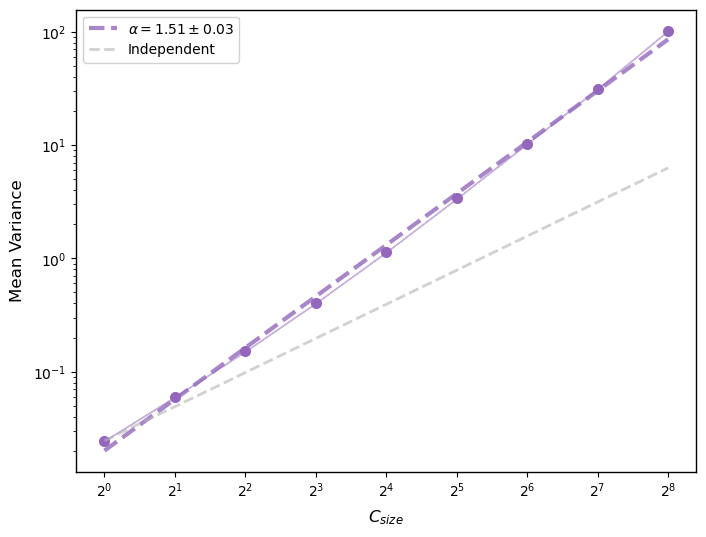

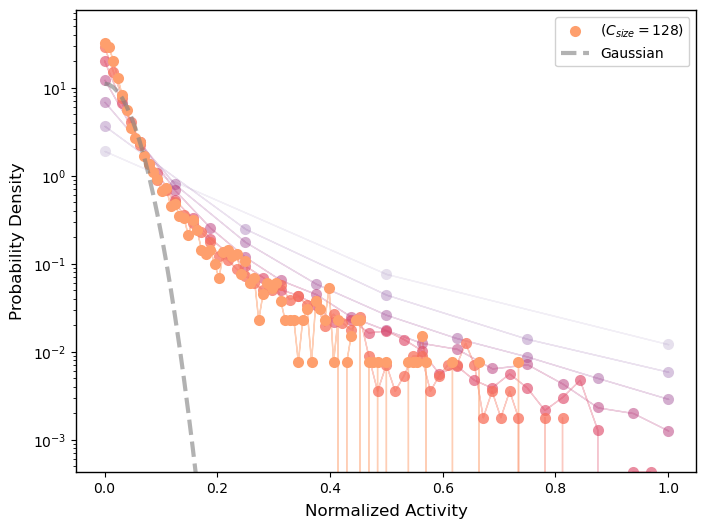

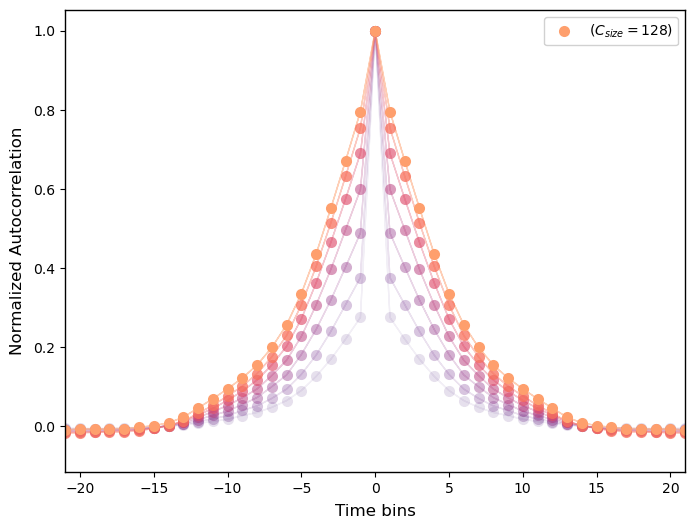

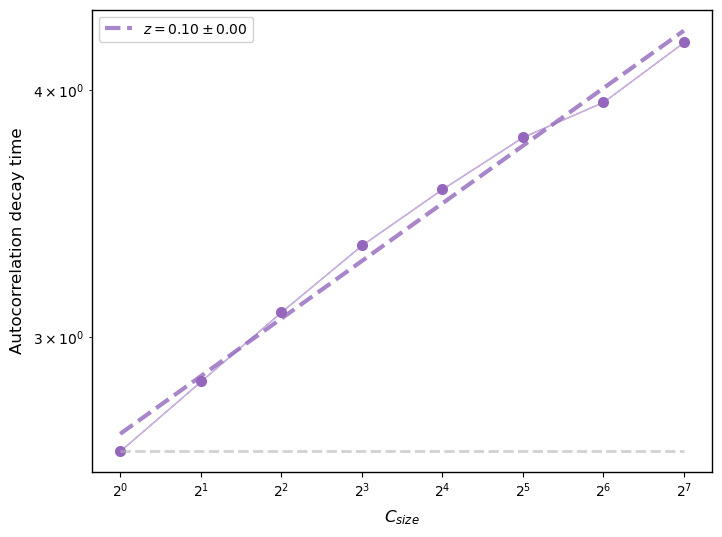

In [2]:
import prg_toolbox as prg
import matplotlib.pyplot as plt


'''
prg_toolbox.config.AnalysisParams() loads all the default 
configurations necessary to run the toolbox.
'''
prg_params = prg.config.AnalysisParams()

'''
We configure the parameters for binarization and PRG analysis
'''
# Set z-score binarization parameters
prg_params.loading.data_format = 'timeseries'  
prg_params.loading.binary_method = 'zscore_threshold'
prg_params.loading.zscore_threshold= 2.0  # Adjust based on your specific data requirements
# PRG parameters
prg_params.rg_steps = 8
prg_params.observables = [prg.mean_variance, prg.activity_distribution, prg.autocorrelation_function, prg.decay_time]

# Run the PRG analysis on the binarized fMRI data
data = prg.tools.load_data('example_rs-fMRI_data.txt')
results = prg.run_PRG(data, user_params=prg_params)


# Plotting the results
# Let's add some styling
prg_params.plot_style.show_legend = True
prg_params.plot_style.plot_kwargs = {'markersize': 8, 'linewidth': 2}
plot_functions = {
    'mean_variance': prg.plot.plot_mean_variance,
    'activity_distribution': prg.plot.plot_activity_distribution,
    'autocorrelation_function': prg.plot.plot_autocorrelation_function,
    'decay_time': prg.plot.plot_decay_time
}

for observable in results:
    fig = plt.figure(figsize=(8,6))
    plot_functions[observable](results[observable], style_config=prg_params)



### Comparing thresholds

We can see how the choice of preprocessing impacts the final analysis. Let's compare the output for analyses with different thresholds:

In [ ]:
import prg_toolbox as prg
import matplotlib.pyplot as plt
import numpy as np

# Load the data once
data = prg.tools.load_data('example_rs-fMRI_data.txt')

# Initialize params
prg_params = prg.config.AnalysisParams()
prg_params.loading.data_format = 'timeseries'  
prg_params.loading.binary_method = 'zscore_threshold'
prg_params.rg_steps = 7
prg_params.observables = [prg.mean_variance, prg.activity_distribution]

# Prepare thresholds and figure containers
thresholds = np.linspace(1.0, 2.0, 5)
fig_mv, ax_mv = plt.subplots(figsize=(8,6))
fig_ad, ax_ad = plt.subplots(figsize=(8,6))
prg_params.plot_style.show_legend = False   # Switch off default legend
colors = plt.cm.magma(np.linspace(0.2, 0.8, len(thresholds)))  # Color map for different thresholds
# Loop over thresholds
for i, z in enumerate(thresholds):
    prg_params.loading.zscore_threshold = z
    results = prg.run_PRG(data, user_params=prg_params)
    
    # Run plotting functions
    # Note: we can pass matplotlib kwargs directly to the plotting functions or through the style_config object
    prg.plot.plot_mean_variance(results['mean_variance'], style_config=prg_params, plot_kwargs={'color':colors[i]}, ax=ax_mv)
    prg.plot.plot_activity_distribution(results['activity_distribution'], style_config=prg_params, plot_kwargs={'color':colors[i]}, ax=ax_ad)

    # Note: To legend multiple lines ind the same plot, we need some external help from matplotlib
    exp_mv = results['mean_variance'].exponent 
    ax_mv.get_lines()[-2].set_label(f'z={z:.1f} (exp={exp_mv:.2f})')
    ax_ad.get_lines()[-2].set_label(f'z={z:.1f}')
ax_mv.legend(title="Mean Variance Exponents")
ax_ad.legend()
plt.show()